In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

## Import dataset

In [2]:
#https://www.kaggle.com/datasets/amirseyyedi/wine-quality/data
df = pd.read_csv("../dataset/wine_quality_red_white.csv")

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [5]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

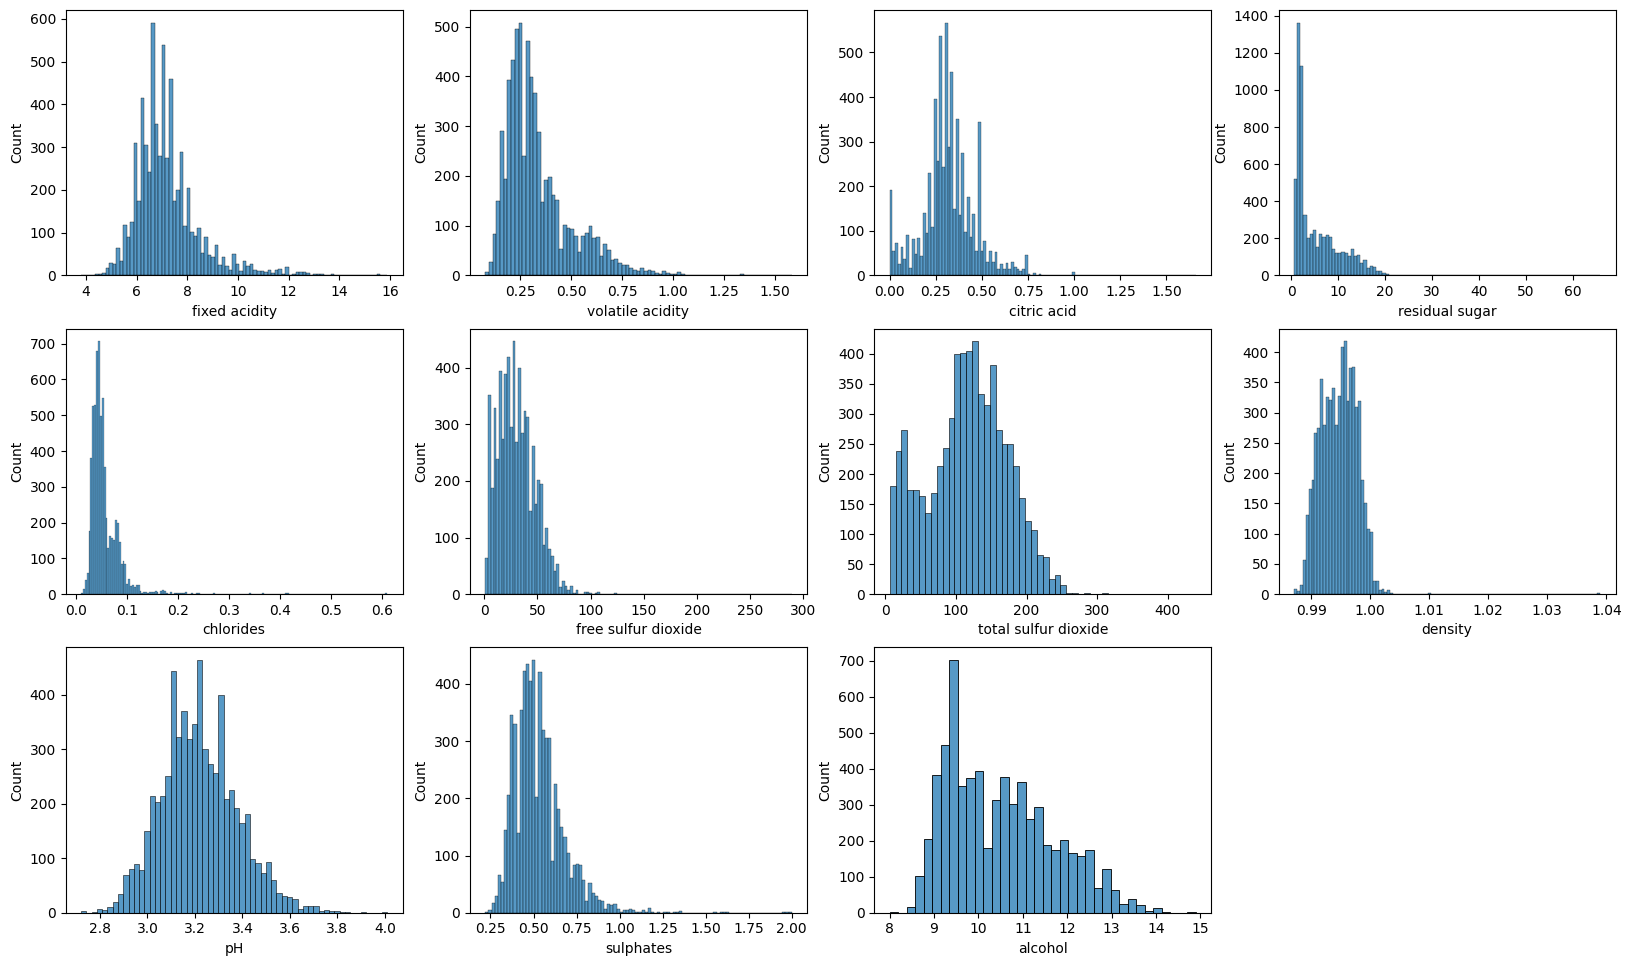

In [6]:
plt.figure(figsize=(20,20))
num_cols = df.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=df[num_cols[i]])


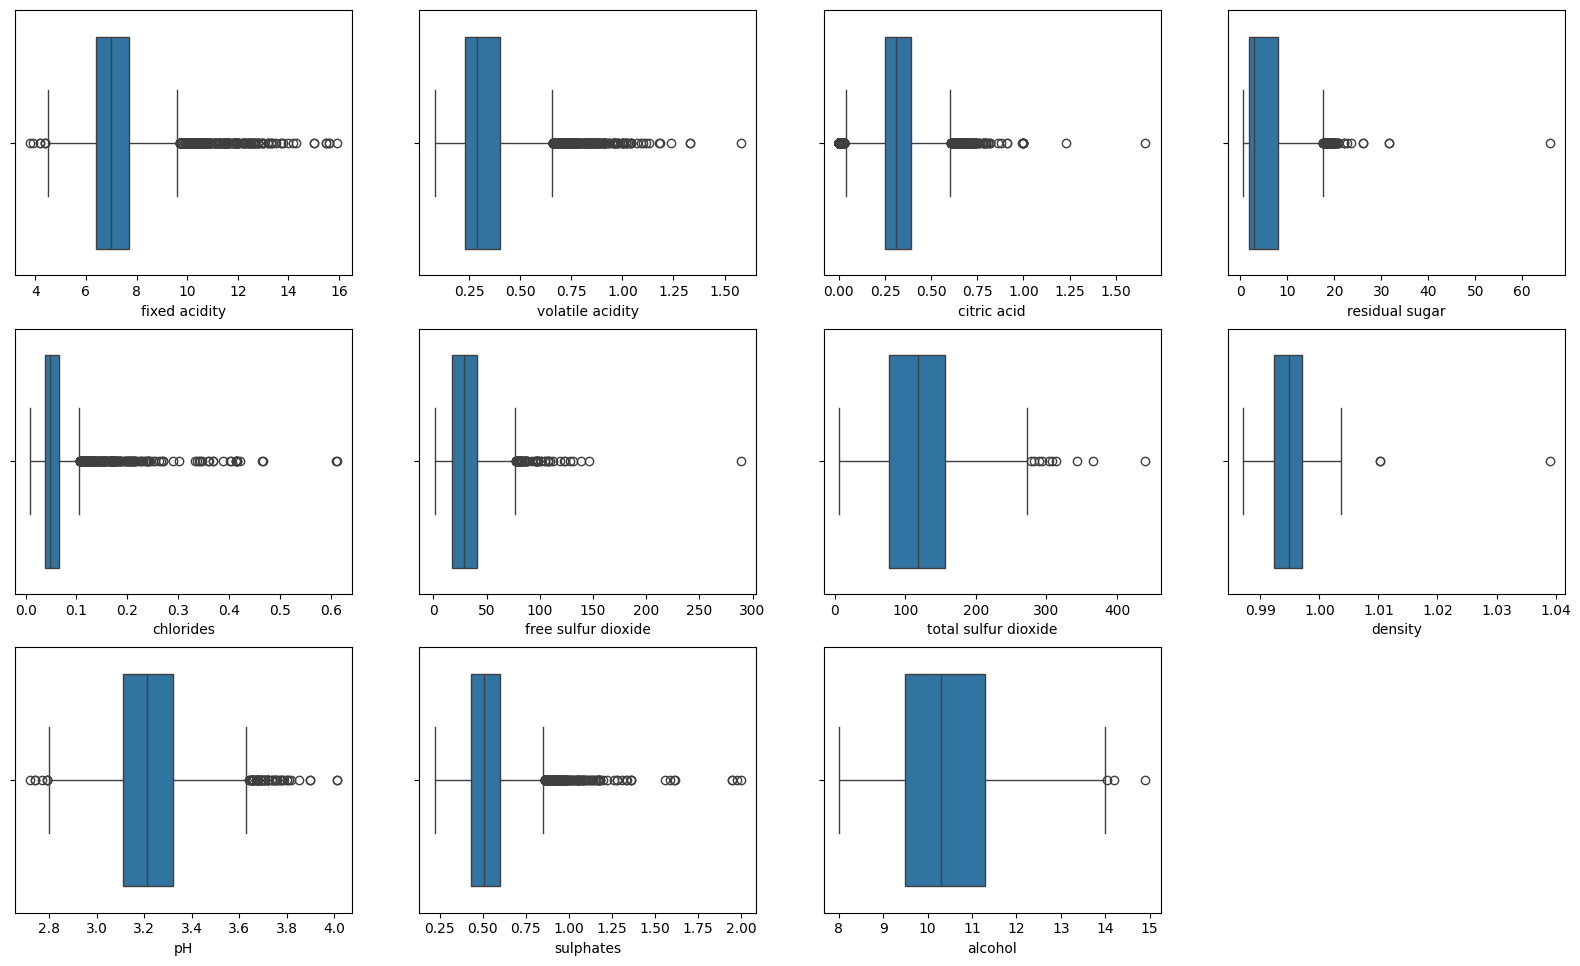

In [7]:
plt.figure(figsize=(20,20))
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.boxplot(x=df[num_cols[i]])

## Feature Engineering 

In [8]:
pt = PowerTransformer(method='yeo-johnson')

df_transformed = df.copy()

cols_to_transform = [col for col in num_cols if col != "density"]

df_transformed[cols_to_transform] = pt.fit_transform(df[cols_to_transform])

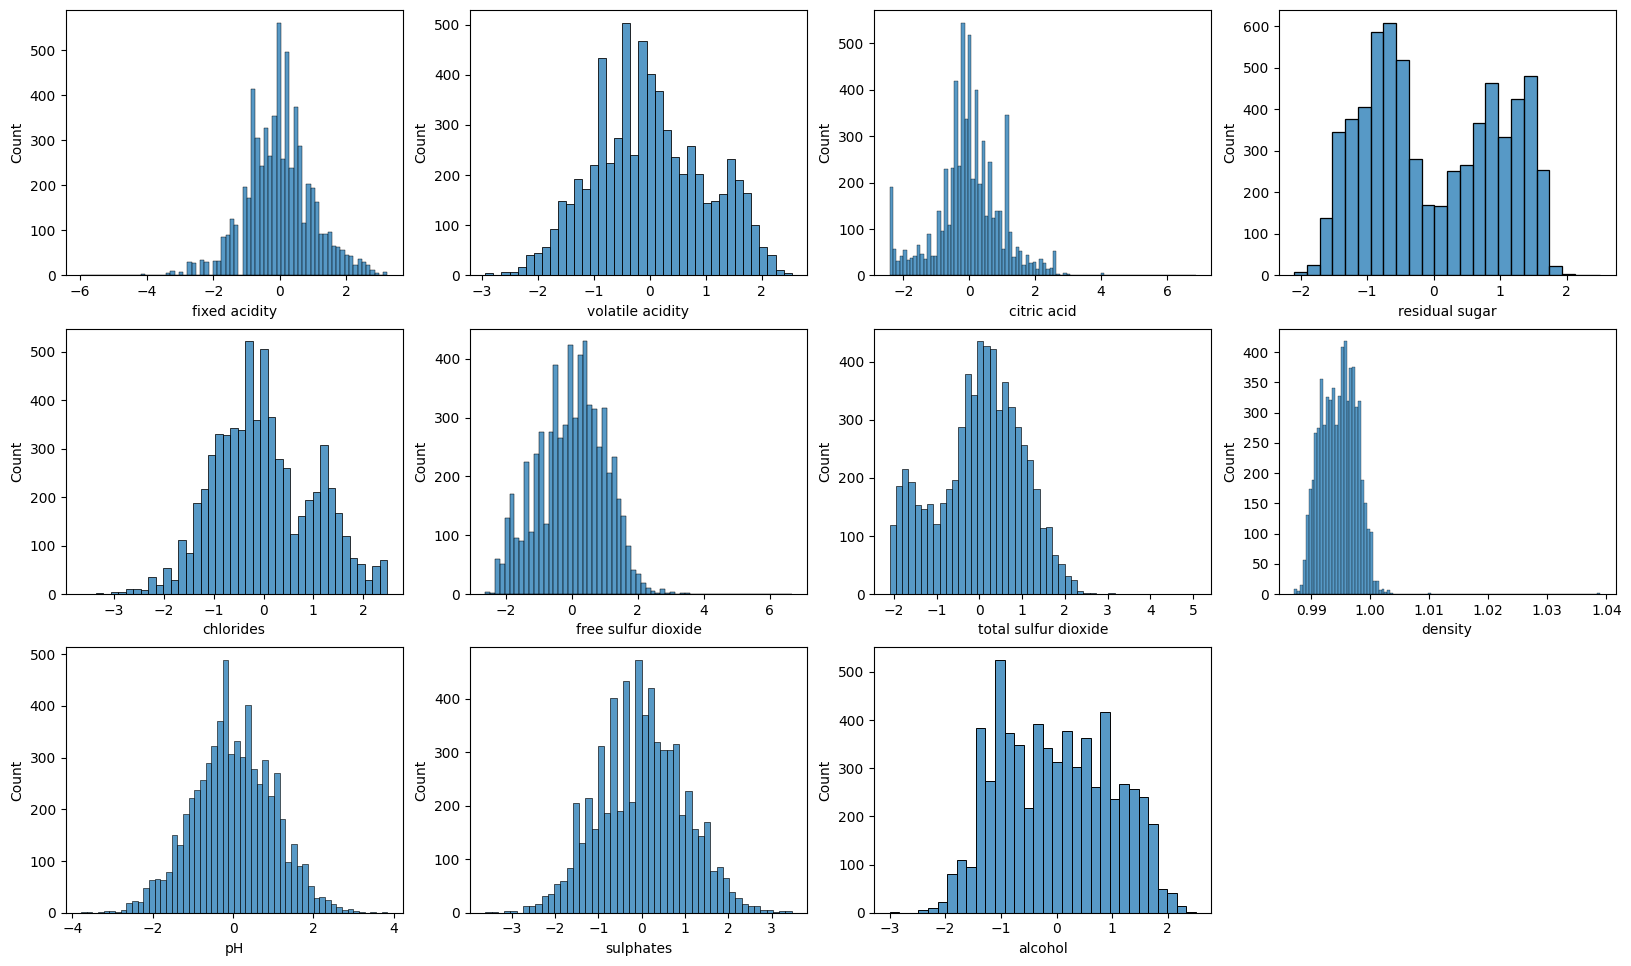

In [9]:
plt.figure(figsize=(20,20))
num_cols = df_transformed.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=df_transformed[num_cols[i]])


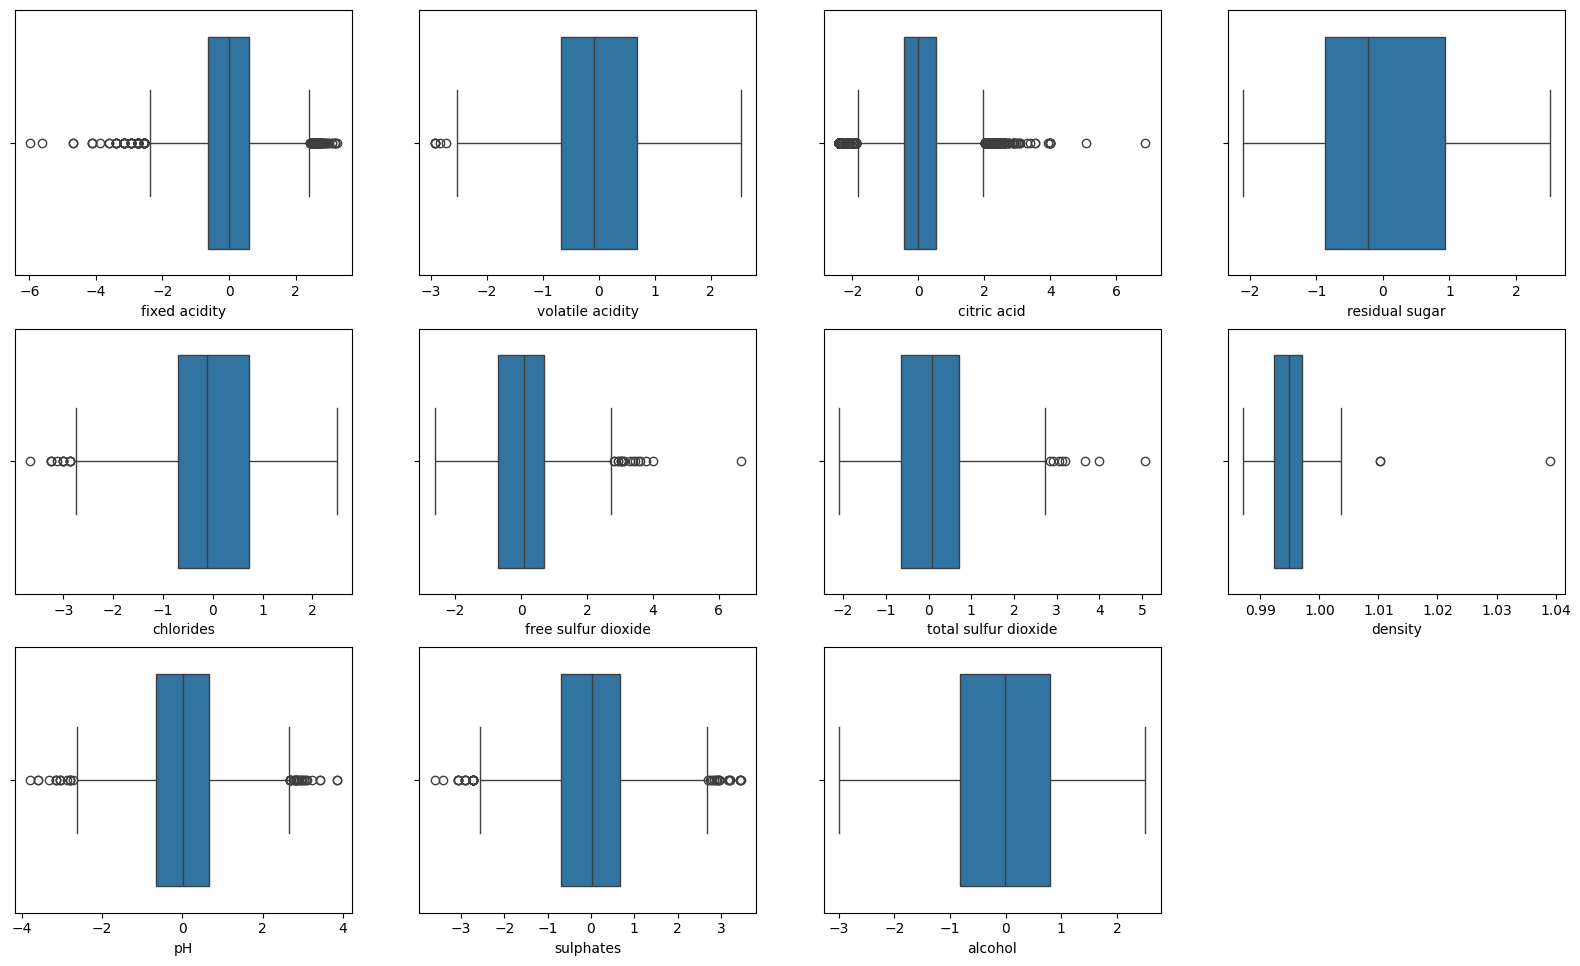

In [10]:
plt.figure(figsize=(20,20))
num_cols = df_transformed.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.boxplot(x=df_transformed[num_cols[i]])


In [11]:
dataframe = df_transformed[df_transformed["density"]<=1.01]
dataframe = dataframe[dataframe["chlorides"] > -3]
dataframe = dataframe[dataframe["fixed acidity"] > -4]
dataframe = dataframe[dataframe["free sulfur dioxide"] < 3]
dataframe = dataframe[dataframe["citric acid"] < 4]
dataframe = dataframe[dataframe["total sulfur dioxide"] < 3]
dataframe = dataframe[dataframe["quality"] != 9]

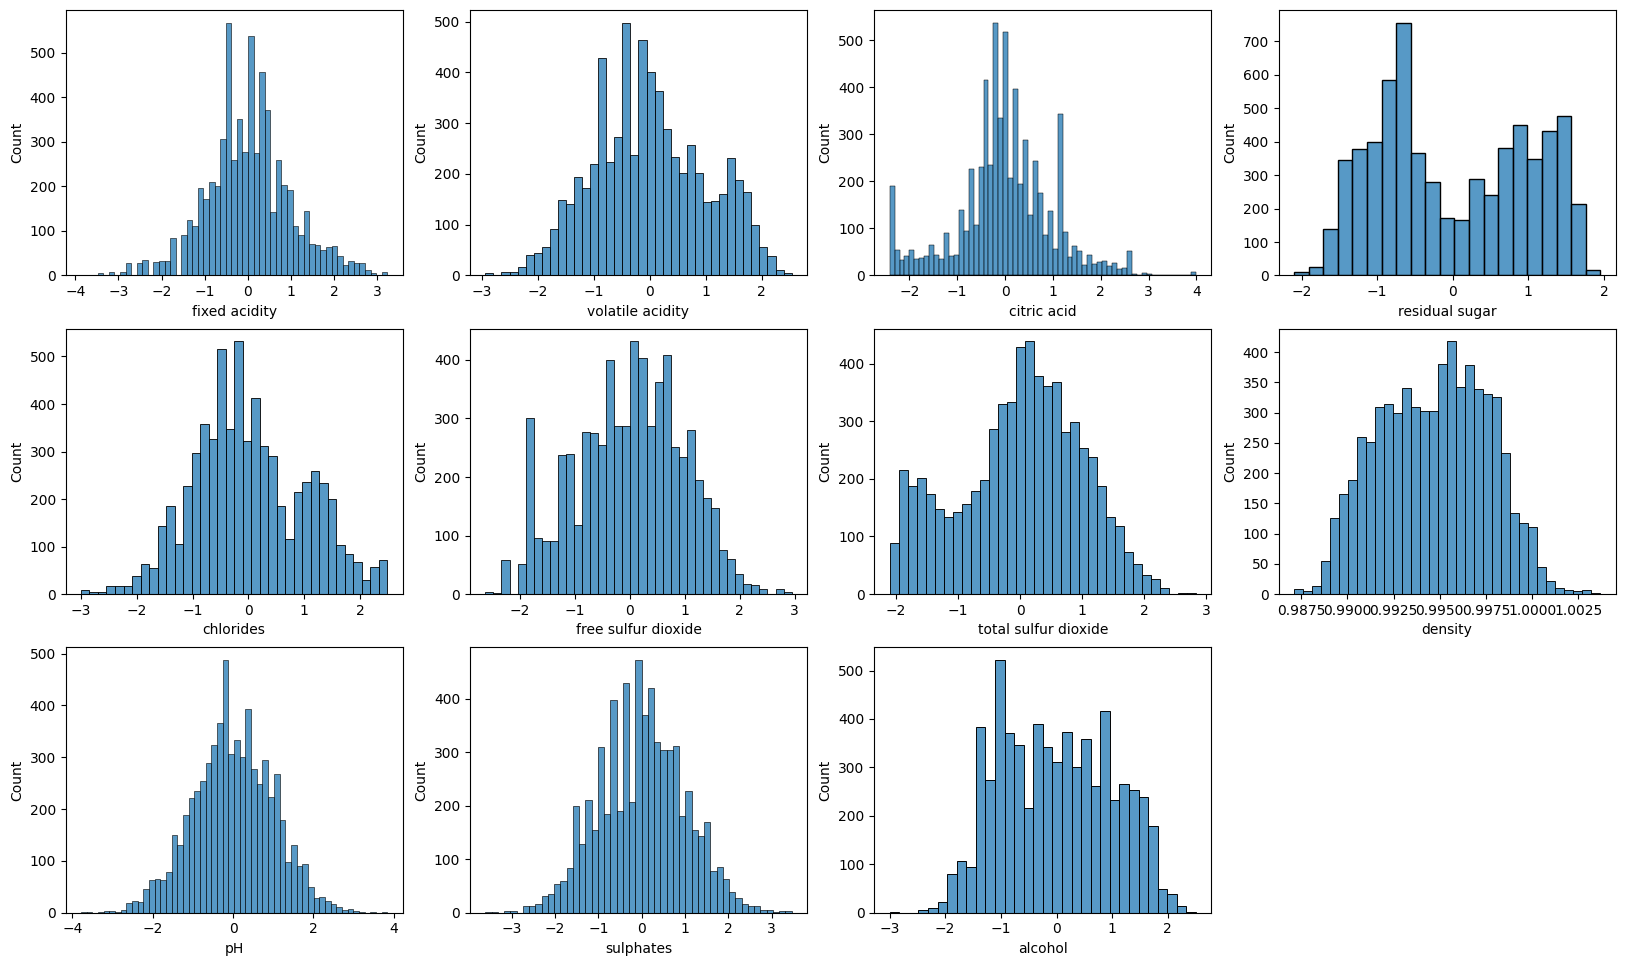

In [12]:
plt.figure(figsize=(20,20))
num_cols = dataframe.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=dataframe[num_cols[i]])


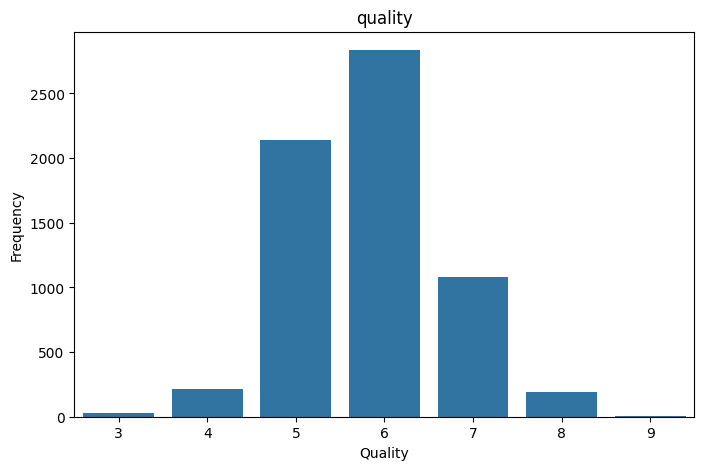

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x=df["quality"])
plt.title("quality")
plt.xlabel("Quality")
plt.ylabel("Frequency")
plt.show()

## Multi-colinearity

Text(0.5, 1.0, 'Correlation Matrix')

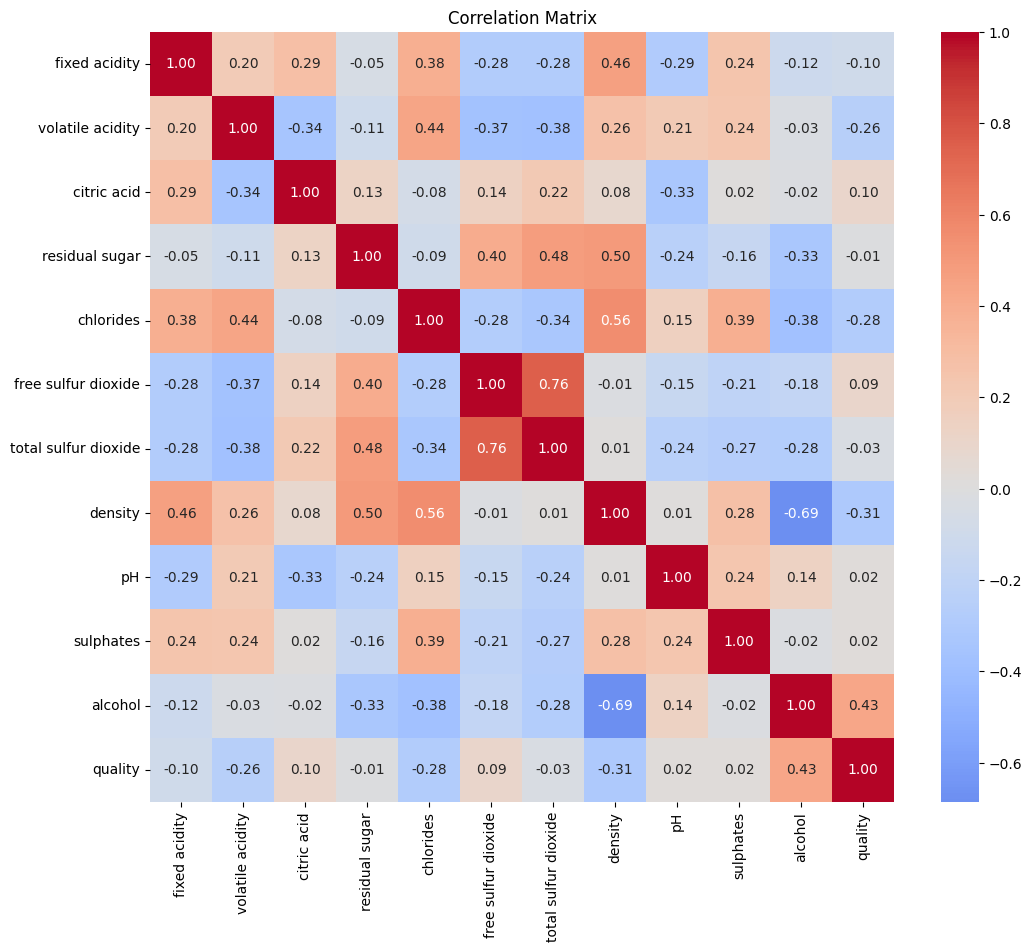

In [14]:
plt.figure(figsize=(12,10))
corr = df_transformed.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")

In [15]:
threshold = 0.8
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

high_corr

[]

In [22]:
from sklearn.preprocessing import StandardScaler
def remove_outliers(df):
    df = df.copy()
    df = df[df["density"] <= 1.01]
    df = df[df["chlorides"] < 0.3]
    df = df[df["fixed acidity"] < 12]
    df = df[df["free sulfur dioxide"] < 100]
    df = df[df["citric acid"] < 0.75]
    df = df[df["total sulfur dioxide"] < 300]
    df = df[df["sulphates"] < 1.25]
    return df

def feature_engineering(df):
    df = df.copy()
    df["type"] = df["type"].map({"red": 0, "white": 1})
    df["quality"] = pd.cut(
        df["quality"],
        bins=[0, 4, 6, 10],
        labels=["Low", "Intermediate", "High"]
    )
    df["quality"] = df["quality"].map({"Low": 0, "Intermediate": 1, "High": 2})
    return df

def split(dataframe, random_state=42, train_size=0.8):
    dataframe = feature_engineering(dataframe)
    X = dataframe.drop(columns=["quality"])
    y = dataframe["quality"]

    

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=(1 - train_size),
        stratify=y,
        random_state=random_state
    )

    train_df = X_train.assign(quality=y_train)
    train_df = remove_outliers(train_df)
    X_train = train_df.drop(columns=["quality"])
    y_train = train_df["quality"]

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        stratify=y_temp,
        random_state=random_state
    )
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_val   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns)
    X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [14]:
df = pd.read_csv("../dataset/wine_quality_red_white.csv")
dataframe = remove_outliers(df)

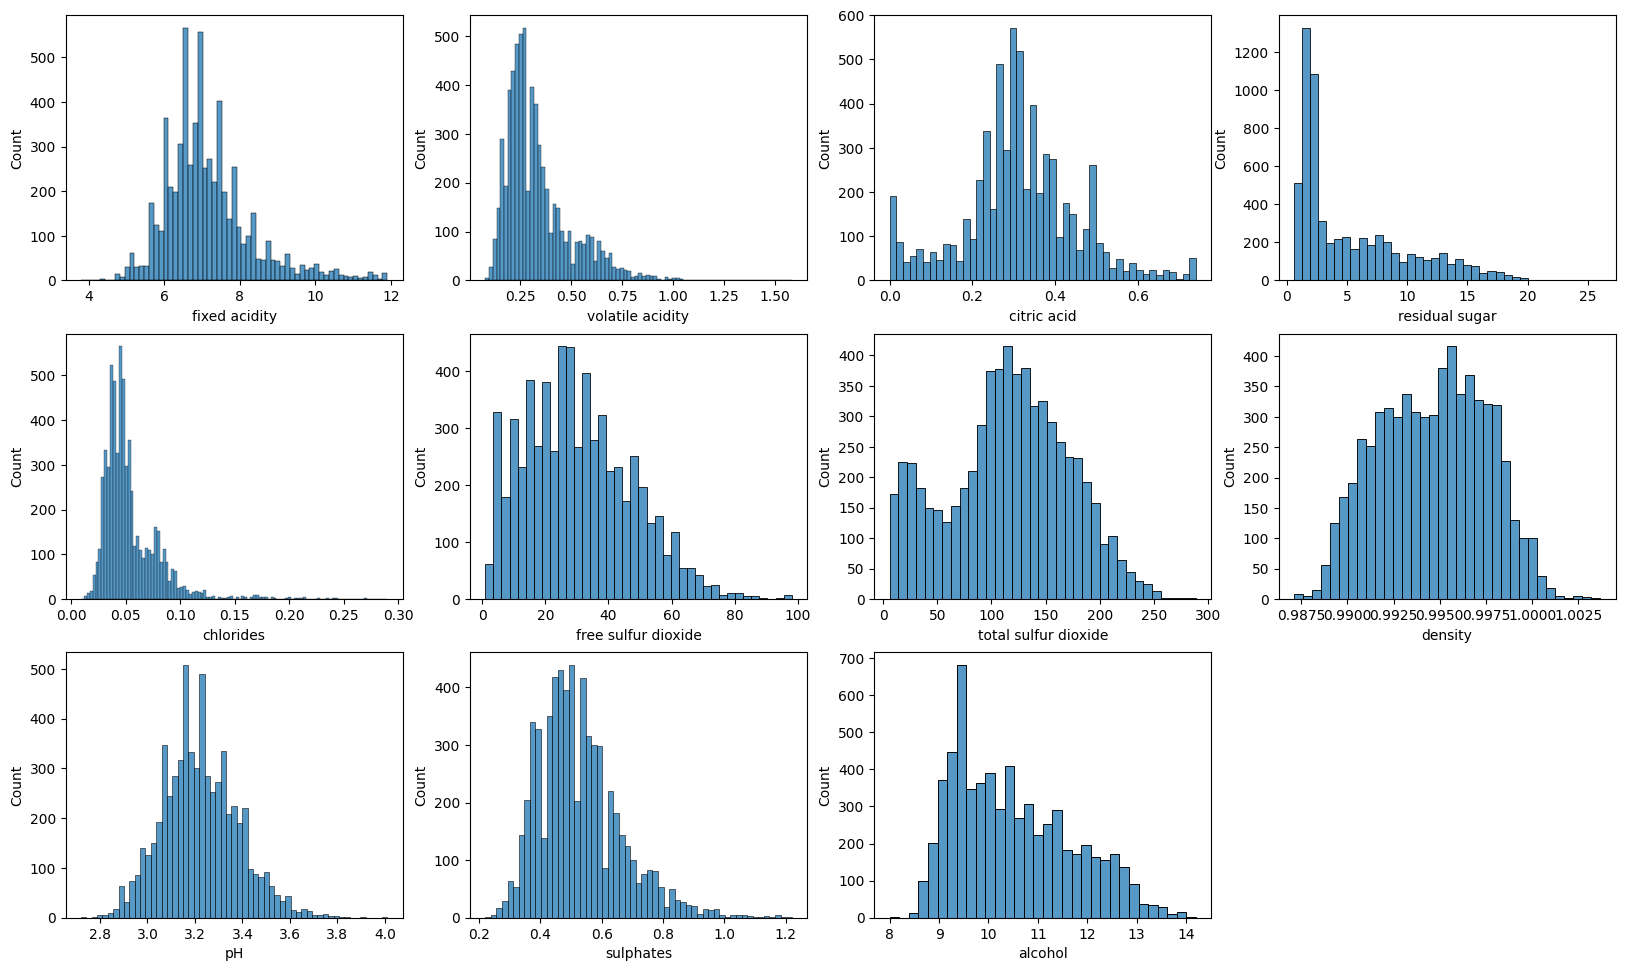

In [15]:
plt.figure(figsize=(20,20))
num_cols = dataframe.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=dataframe[num_cols[i]])


In [16]:
X_train, X_val, X_test, y_train, y_val, y_test = split(df)

In [6]:
y_train.value_counts()

quality
1    3889
2    1006
0     188
Name: count, dtype: int64

In [7]:
def power_transform(dataframe):
    pt = PowerTransformer(method="yeo-johnson")
    df = dataframe.copy()
    cols_to_transform = [col for col in num_cols if col != "density"]
    df[cols_to_transform] = pt.fit_transform(dataframe[cols_to_transform])
    return df

In [8]:
X_train_v2 = power_transform(X_train)

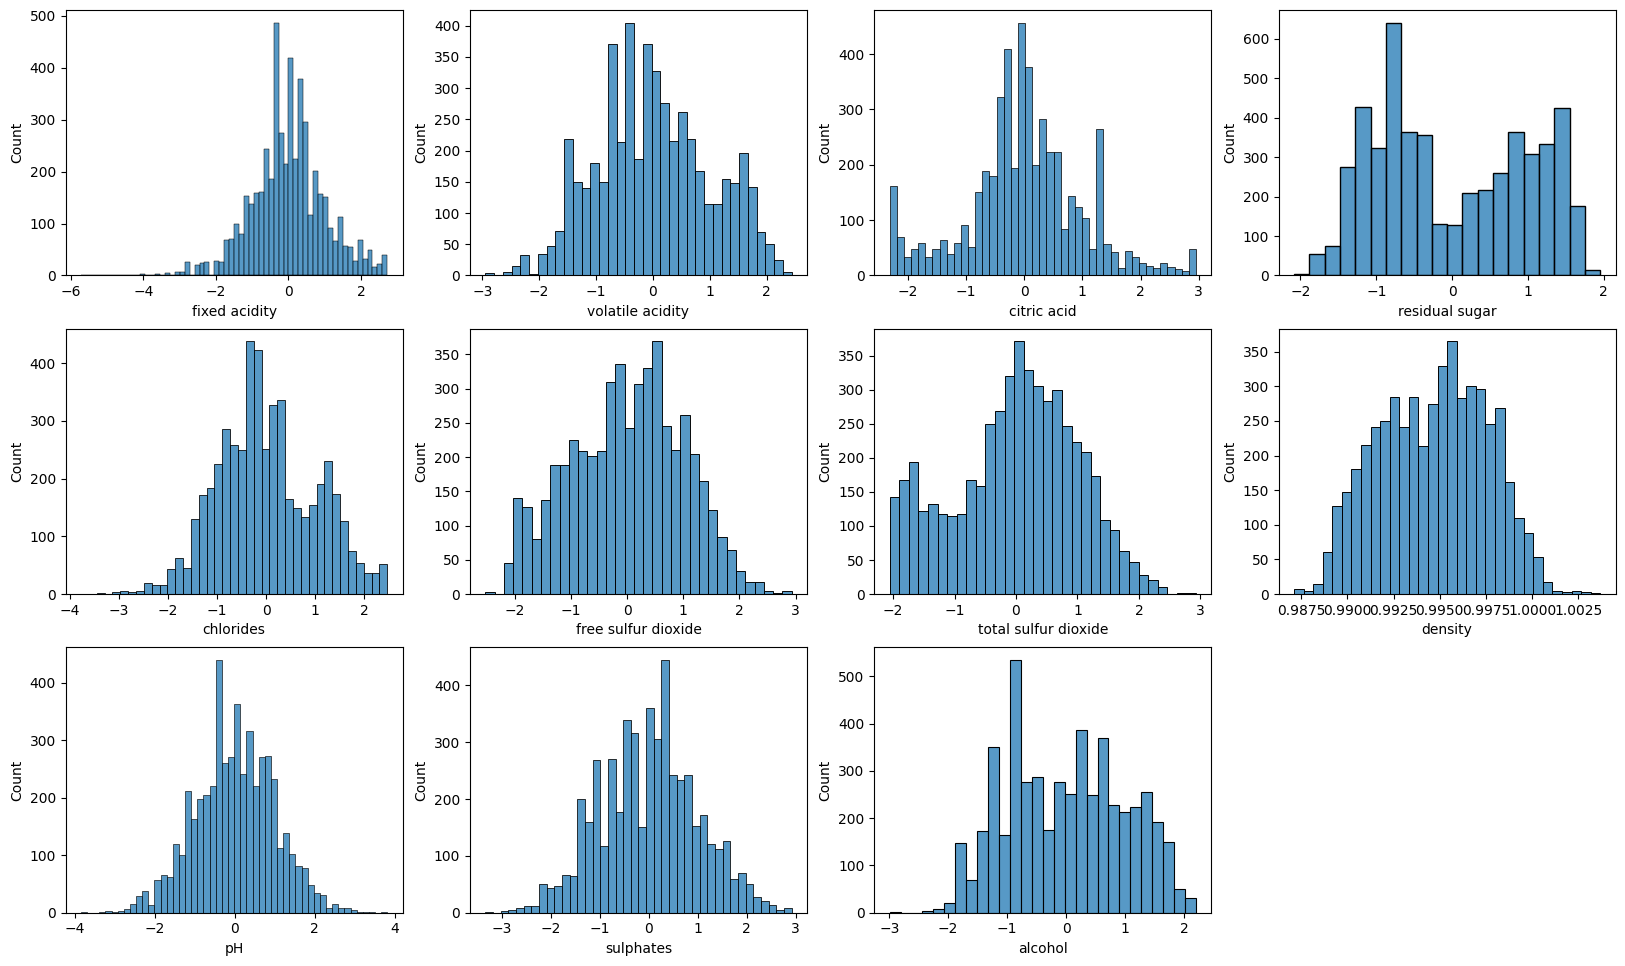

In [95]:
plt.figure(figsize=(20,20))
num_cols = X_train_v2.select_dtypes("float").columns
for i in range(len(num_cols)):
    plt.subplot(5,4,i+1)
    sns.histplot(x=X_train_v2[num_cols[i]])

## Testing classification models

In [9]:
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.class_weight import compute_sample_weight

In [111]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import make_scorer

def train_XGBoost(X_train, y_train, X_val, y_val):
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    param_dist = {
        'n_estimators': randint(200, 1000),
        'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
        'max_depth': randint(3, 15),
        'min_child_weight': randint(1, 15),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5),
        'gamma': uniform(0, 0.5),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0.5, 2),
    }
    xgb_clf = XGBClassifier(
        random_state=42,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss'
    )

    kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

    random_search = RandomizedSearchCV(
        estimator=xgb_clf,
        param_distributions=param_dist,
        n_iter=200,
        cv=5,
        scoring={'f1': 'f1_weighted', 'kappa': kappa_scorer},
        refit='f1',                 # seleciona o melhor modelo por f1
        return_train_score=True,
        random_state=42,
        n_jobs=-1
    )

    print("Starting the hyperparameter fitting. This can take some time...")
    random_search.fit(X_train, y_train, sample_weight=sample_weights)
    print("Finished!")

    results = random_search.cv_results_
    best_val_score = -float('inf')
    best_estimator = None
    best_params = None

    for params in results['params']:
        model = XGBClassifier(
            random_state=42,
            objective='multi:softmax',
            num_class=3,
            eval_metric='mlogloss',
            **params
        )
        model.fit(X_train, y_train, sample_weight=sample_weights)
        val_preds = model.predict(X_val)
        val_kappa = cohen_kappa_score(y_val, val_preds, weights='quadratic')

        if val_kappa > best_val_score:
            best_val_score = val_kappa
            best_estimator = model
            best_params = params

    print(f"Best validation Kappa: {best_val_score:.4f}")

    return best_estimator, best_params

In [113]:
estimator, params = train_XGBoost(X_train, y_train, X_val, y_val)

Starting the hyperparameter fitting. This can take some time...
Finished!
Best validation Kappa: 0.5583


In [10]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score

def train_XGBoost(X_train, y_train, X_val, y_val):
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    param_dist = {
        'n_estimators': randint(200, 1000),
        'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
        'max_depth': randint(3, 15),
        'min_child_weight': randint(1, 15),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5),
        'gamma': uniform(0, 0.5),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0.5, 2),
    }
    xgb_clf = XGBClassifier(
        random_state=42,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss'
    )

    random_search = RandomizedSearchCV(
        estimator=xgb_clf,
        param_distributions=param_dist,
        n_iter=200,
        cv=5,
        scoring='f1_weighted',
        refit=True,
        return_train_score=True,
        random_state=42,
        n_jobs=-1
    )

    print("Starting the hyperparameter fitting. This can take some time...")
    random_search.fit(X_train, y_train, sample_weight=sample_weights)
    print("Finished!")

    results = random_search.cv_results_
    best_val_score = -float('inf')
    best_estimator = None
    best_params = None

    for params in results['params']:
        model = XGBClassifier(
            random_state=42,
            objective='multi:softmax',
            num_class=3,
            eval_metric='mlogloss',
            **params
        )
        model.fit(X_train, y_train, sample_weight=sample_weights)
        val_preds = model.predict(X_val)
        val_f1 = f1_score(y_val, val_preds, average='weighted')

        if val_f1 > best_val_score:
            best_val_score = val_f1
            best_estimator = model
            best_params = params

    print(f"Best validation F1: {best_val_score:.4f}")

    return best_estimator, best_params

In [11]:
estimator, params = train_XGBoost(X_train, y_train, X_val, y_val)

Starting the hyperparameter fitting. This can take some time...
Finished!
Best validation F1: 0.8282


In [20]:
# predições no teste
y_pred = estimator.predict(X_test)

# F1 (multiclasse → precisa de average)
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test F1: {f1:.4f}")

Test F1: 0.9252
